In [34]:
#basic libraries
import pandas as pd
import numpy as np
import matplotlib as plt

#preprocessing libraries
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

#ML models
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

#ANN libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from tensorflow.keras.models import load_model
#others
import datetime
import joblib


In [35]:
#loading all models

model = load_model('model.h5')

scaler = joblib.load('scaler.pkl')

In [36]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,691 (10.52 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [37]:
#test input data

input = {'Credit Amount' : [16500],
         'gender' : [1],
          'Education level': [4],
          'Marital Status': [2],
           "Age" : [56],
           'totall bill statement' : [2342343],
            'total amount paid': [234324],
             'avg repayment': [6]}




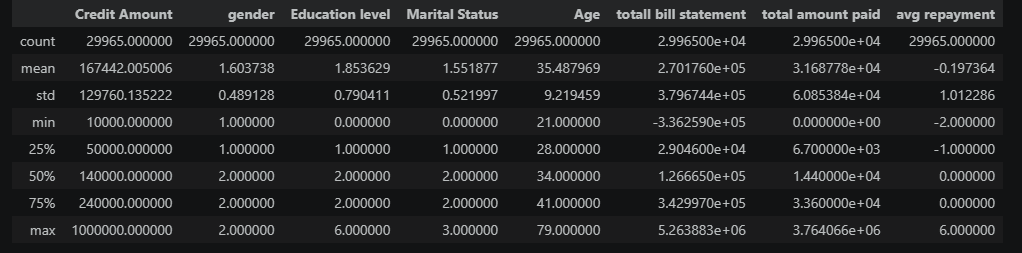

In [38]:
list(input.keys())

['Credit Amount',
 'gender',
 'Education level',
 'Marital Status',
 'Age',
 'totall bill statement',
 'total amount paid',
 'avg repayment']

In [39]:
#scale values first 

inputdf = pd.DataFrame(input)


num_features = inputdf[['Credit Amount', 'Age', 'totall bill statement','total amount paid', 'avg repayment']]

num_features = scaler.transform(num_features)

inputdf.drop(['Credit Amount', 'Age', 'totall bill statement','total amount paid', 'avg repayment'], axis= 1, inplace= True)

input = np.concatenate([inputdf, num_features],axis = 1)

In [40]:
print(input)

[[ 1.          4.          2.         -1.16102488  2.21888889  5.50008367
   3.59404798  6.09035395]]


In [43]:
#make prediction with ANN
prediction = model.predict(input)
prediction[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


np.float32(0.7003295)